In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB , MultinomialNB ,BernoulliNB
from sklearn.metrics import accuracy_score
#bonus
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("churn_dataset.xlsx")
df

,Age,Tenure,Sex,Churn
0,56,8,Male,No
1,46,63,Female,No
2,32,11,Female,No
3,60,8,Male,No
4,25,35,Male,No
...,...,...,...,...
95,24,38,Female,No
96,26,24,Male,No
97,41,69,Female,Yes
98,18,70,Male,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Age     100 non-null    int64
 1   Tenure  100 non-null    int64
 2   Sex     100 non-null    str  
 3   Churn   100 non-null    str  
dtypes: int64(2), str(2)
memory usage: 3.3 KB


In [4]:
df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [5]:
print(df.isnull().sum())

Age       0
Tenure    0
Sex       0
Churn     0
dtype: int64


In [6]:
X = df[['Age', 'Tenure', 'Sex']]
y = df['Churn']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [9]:
import joblib
joblib.dump(model, 'my_model.pkl')

print("Model saved successfully in my_model.pkl")

Model saved successfully in my_model.pkl


In [10]:
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.8


#### >>>> Accuracy: 0.8 

In [11]:
cm = confusion_matrix(y_test, y_pred)

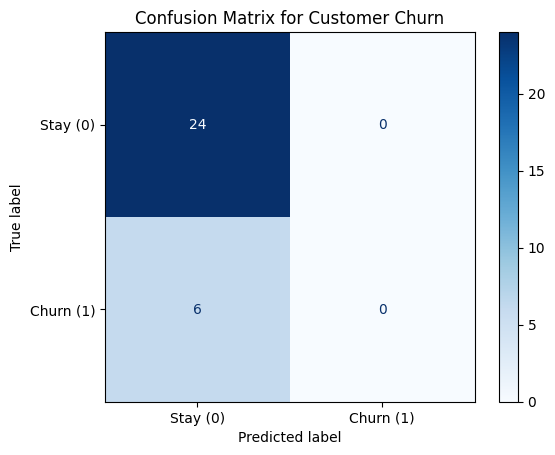

In [12]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Churn (1)'])
disp.plot(cmap=plt.cm.Blues) 
plt.title('Confusion Matrix for Customer Churn')
plt.show() 